In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\user\Downloads\tesla-stock-price.csv")
print(df.shape)
print(df.head())

(757, 6)
         date   close         volume    open    high       low
0       11:34  270.49      4,787,699  264.50  273.88  262.2400
1  2018/10/15  259.59   6189026.0000  259.06  263.28  254.5367
2  2018/10/12  258.78   7189257.0000  261.00  261.99  252.0100
3  2018/10/11  252.23   8128184.0000  257.53  262.25  249.0300
4  2018/10/10  256.88  12781560.0000  264.61  265.51  247.7700


In [3]:
print("null values:",df.isnull().sum())

null values: date      0
close     0
volume    0
open      0
high      0
low       0
dtype: int64


In [4]:

# Fix date column
df = df[df['date'].str.contains('2018|2017|2016|2015|2014')]
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.reset_index(drop=True)

print("Clean shape:", df.shape)
print(df.head())

Clean shape: (756, 6)
        date   close         volume    open      high     low
0 2015-10-15  221.31   2835920.0000  216.43  221.7300  213.70
1 2015-10-16  227.01   4327574.0000  223.04  230.4805  222.87
2 2015-10-19  228.10   2506836.0000  226.50  231.1500  224.94
3 2015-10-20  213.03  14877020.0000  227.72  228.6000  202.00
4 2015-10-21  210.09   4177956.0000  211.99  214.8100  208.80


In [5]:
print("\nMissing values:", df.isnull().sum().sum())
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Price range: $", df['close'].min(), "to $", df['close'].max())


Missing values: 0

Date range: 2015-10-15 00:00:00 to 2018-10-15 00:00:00
Price range: $ 143.67 to $ 385.0


In [6]:
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month')['close'].mean()
print("\nMonthly average price:")
print(monthly)


Monthly average price:
month
2015-10    214.790000
2015-11    220.882000
2015-12    230.171818
2016-01    204.562105
2016-02    169.670000
2016-03    216.147273
2016-04    250.959048
2016-05    216.633810
2016-06    214.839091
2016-07    223.379000
2016-08    223.734348
2016-09    202.256190
2016-10    201.683333
2016-11    189.157619
2016-12    200.552857
2017-01    239.320500
2017-02    263.711053
2017-03    258.156522
2017-04    304.758421
2017-05    316.524091
2017-06    365.803636
2017-07    328.805000
2017-08    350.875217
2017-09    357.857000
2017-10    344.683182
2017-11    310.191905
2017-12    322.841000
2018-01    338.583333
2018-02    335.777105
2018-03    315.983333
2018-04    289.772619
2018-05    289.852273
2018-06    335.600476
2018-07    311.974762
2018-08    331.214348
2018-09    290.147895
2018-10    271.921818
Freq: M, Name: close, dtype: float64


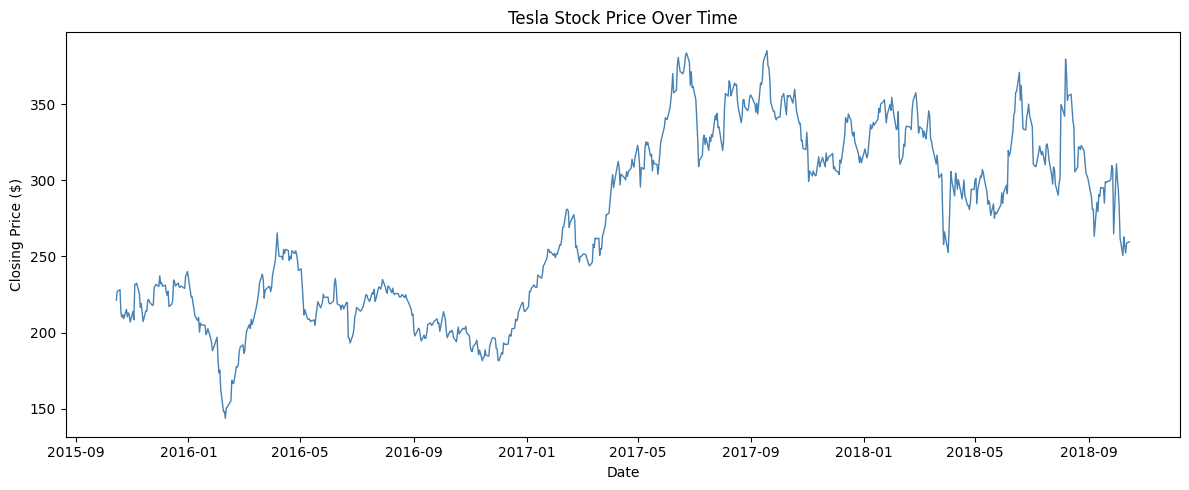

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['close'], color='steelblue', linewidth=1)
plt.title('Tesla Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.tight_layout()
plt.show()

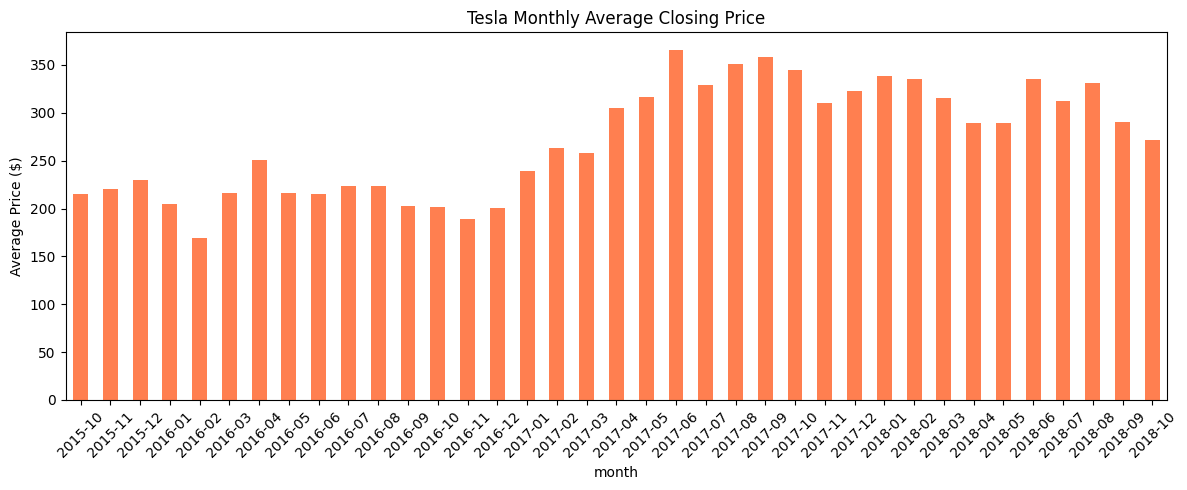

In [8]:
monthly.plot(kind='bar', color='coral', figsize=(12,5))
plt.title('Tesla Monthly Average Closing Price')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df['weekday'] = df['date'].dt.day_name()
weekly = df.groupby('weekday')['close'].mean()
weekly = weekly.reindex(['Monday','Tuesday','Wednesday',
                         'Thursday','Friday'])
print("\nAverage price by weekday:")
print(weekly)



Average price by weekday:
weekday
Monday       273.316143
Tuesday      272.307806
Wednesday    273.001419
Thursday     272.631916
Friday       272.037730
Name: close, dtype: float64


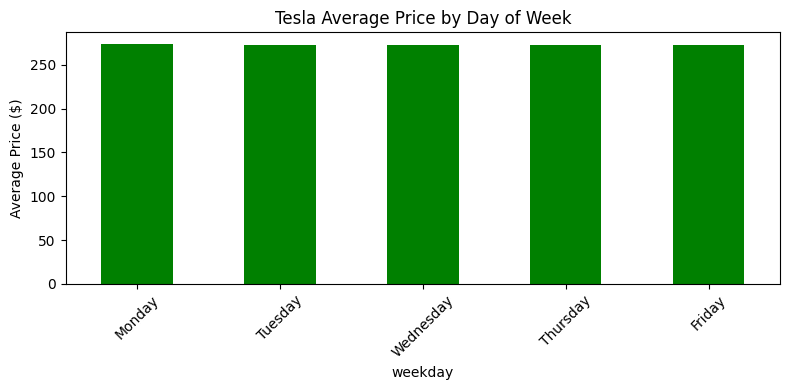

In [10]:
weekly.plot(kind='bar', color='green', figsize=(8,4))
plt.title('Tesla Average Price by Day of Week')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
best_day = weekly.idxmax()
worst_day = weekly.idxmin()
print(f"\nFinal Insight:")
print(f"Best day to buy: {worst_day} (lowest avg price)")
print(f"Best day to sell: {best_day} (highest avg price)")


Final Insight:
Best day to buy: Friday (lowest avg price)
Best day to sell: Monday (highest avg price)
